<h3>In our exercises we aim to explore the contextual relevance of our work at a bit more depth. The lectures are full of basic examples, but we really learn to code by - you guessed it - writing code!</h3>

We are going to combine some of the basic techniques we have learned and at the same time explore some libraries that get us up to speed <b>quickly</b> and <b>efficiently</b>. Let's get started.

<h1> Activity 1 </h1>

<h3>To lemmatize or stem? It's a good question!</h3>

lemmatize is good for finding a (meaningful) word that is synonymous <b>and</b> has meaning
stemming is similar, but will find the root of the word. It also might come up with nonsense words as 'roots' do not need to be meaningful.

These techniques might come in useful if you have words of a similar 'ilk' and do not care to distinguish between them. The libraries will allow you to identify words in context so for example variations of a word may be verbs, adjectives, nouns etc.

Try out a few variations of words e.g. dancer, dancing, dances etc and see if you can identify a pattern. Word categorisation is harder than it looks! Even when the words are very similar. Let's explore the two main approaches.

In [1]:
import sys
!{sys.executable} -m pip install nltk
!{sys.executable} -m pip install wordcloud

# Starting with the word chase we will try to find variations of the word 'root' or 'origin'.

import nltk
from nltk.stem import PorterStemmer
nltk.download('wordnet')

word = 'Chase'

porter = PorterStemmer()
print("Stemmed word: " + porter.stem(word))

# The stemmed version produces 'danc'

from nltk.stem import WordNetLemmatizer
wordnet_lemmatizer = WordNetLemmatizer()
print("Lemmatized word: " + wordnet_lemmatizer.lemmatize(word))

# Extension activity 1: Using a ["list", "of", "words"]
word_list = ['chase', 'chasing', 'chaser', 'chased', 'chases']

# Extension activity 2: Iterating through a list of words 

for w in word_list:
    print("Porter Stemmed word is " + w + ": " + porter.stem(w))
    
for w in word_list:
    print("Lemmatized word is " + w + ": " + wordnet_lemmatizer.lemmatize(w))


You should consider upgrading via the '/opt/conda/bin/python -m pip install --upgrade pip' command.
You should consider upgrading via the '/opt/conda/bin/python -m pip install --upgrade pip' command.


[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Stemmed word: chase
Lemmatized word: Chase
Porter Stemmed word is chase: chase
Porter Stemmed word is chasing: chase
Porter Stemmed word is chaser: chaser
Porter Stemmed word is chased: chase
Porter Stemmed word is chases: chase
Lemmatized word is chase: chase
Lemmatized word is chasing: chasing
Lemmatized word is chaser: chaser
Lemmatized word is chased: chased
Lemmatized word is chases: chase


<h3> Additional Resources </h3>
NLTK also has categorisation and tagging options. These are beyond the scope of this course <b>but</b>
If you do wish to explore these, the documentation can be found <a href="https://www.nltk.org/book/ch05.html">here</a>.

Section 1 Using a Tagger and Section 2 Tagged Corpora might be particularly useful resources for your coursework

<h1> Activity 2 </h1>

When working with text we often try to generate a high level overview of a corpus to determine things like its suitability for analysis and general structure/themes. There are a few ways we can do this. Let's begin with our high level analysis of the features of the text - starting with a familiar concept, term frequency!

[nltk_data] Downloading package punkt to /home/jovyan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Without stop words: ['chasing', 'cars', 'morning', '.', 'evening', ',', "n't", 'chasing', 'cars', '.', 'read', 'books', '.']
With stop words: ['i', 'like', 'chasing', 'cars', 'in', 'the', 'morning', '.', 'in', 'the', 'evening', 'however', ',', 'i', 'really', 'do', "n't", 'like', 'chasing', 'cars', '.', 'i', 'would', 'rather', 'read', 'books', '.']
<FreqDist with 18 samples and 27 outcomes>


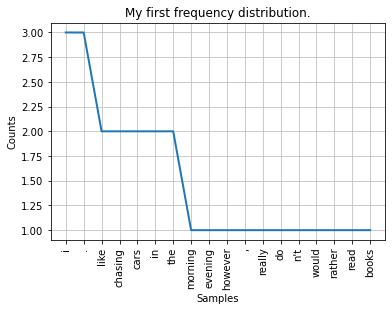

In [2]:
# example two, plotting popular words

import nltk
nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.probability import FreqDist

sentence="I like chasing cars in the morning. In the evening however, I really don't like chasing cars. I would rather read books."

# convert sentence words to lower case
sentence = sentence.lower()

tokens = nltk.tokenize.word_tokenize(sentence)

# Remove stopwords
filtered = [word for word in tokens if not word in stopwords.words()]
print("Without stop words:", filtered)

f_dist = FreqDist(tokens)

print("With stop words:", tokens)
print(f_dist)

# # Plot the data we have. 
import matplotlib.pyplot as plt
fd = nltk.FreqDist(tokens)

# Feed our plot all words as a parameter for our plot. We also want to set cumulative as 'false'
fd.plot(18,cumulative=False, title="My first frequency distribution.")

<h1> Activity 3 </h1>
<h3>Sentiment analysis is another way to contextualise words and their associated meaning. </h3>

We can think of sentiment as either positive or negative, but this is a spectrum. 'Good' is not the same as 'Great.' It's good, but it's not great! I like chocolate but love coffee. If you gave me the choice of either chocolate or coffee, I'd always choose coffee!

Some words perhaps do not have any sentiment at all, e.g. table, cabbage.

We will use a popular library for social media data analysis to quickly calculate some metrics and see how we can turn a word into a quantifiable metric based on some predefined rules.

In [10]:
# Detect sentiment - the easy way

from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Load the Lexicon that quantifies polar sentiment (positive/negative)
nltk.download('vader_lexicon')

analyzer=SentimentIntensityAnalyzer()

# Original sentence
sentence="I like chasing cars in the morning. In the evening however, I really don't like chasing cars. I would rather read books."
sentence = sentence.lower()
print(sentence)
print(analyzer.polarity_scores(sentence))
print('\n')
# "I would rather.." is categorised as neutral which was surprising to me!

# Does the order of words matter?
sentence="I would rather read books. In the evening however, I really don't like chasing cars. I like chasing cars in the morning."
sentence = sentence.lower()
print(sentence)
print(analyzer.polarity_scores(sentence))
print('\n')
# The order of the words does matter.Shifting the sentences around has increased the negativity score.

# Using love and hate really increase both the positivity and negativity scores
sentence="I love chasing cars in the morning. In the evening however, I like chasing cars. I hate to read books."
sentence = sentence.lower()
print(sentence)
print(analyzer.polarity_scores(sentence))
print('\n')

# Preceding like with "don't" also changes like from positive to negative.
sentence="I don't like chasing cars in the morning. In the evening however, I like chasing cars. I love to read books."
sentence = sentence.lower()
print(sentence)
print(analyzer.polarity_scores(sentence))
print('\n')

# Removing all occurrences of "don't" and "hate" removed all negativity from the sentences.
sentence="I like chasing cars in the morning. In the evening however, I love chasing cars. I also like to read books."
sentence = sentence.lower()
print(sentence)
print(analyzer.polarity_scores(sentence))
print('\n')


i like chasing cars in the morning. in the evening however, i really don't like chasing cars. i would rather read books.
{'neg': 0.0, 'neu': 0.773, 'pos': 0.227, 'compound': 0.6124}


i would rather read books. in the evening however, i really don't like chasing cars. i like chasing cars in the morning.
{'neg': 0.219, 'neu': 0.781, 'pos': 0.0, 'compound': -0.5827}


i love chasing cars in the morning. in the evening however, i like chasing cars. i hate to read books.
{'neg': 0.152, 'neu': 0.574, 'pos': 0.275, 'compound': 0.4588}


i don't like chasing cars in the morning. in the evening however, i like chasing cars. i love to read books.
{'neg': 0.18, 'neu': 0.64, 'pos': 0.179, 'compound': 0.2453}


i like chasing cars in the morning. in the evening however, i love chasing cars. i also like to read books.
{'neg': 0.0, 'neu': 0.62, 'pos': 0.38, 'compound': 0.8481}




[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


<h1> Activity 4 </h1>
<h3> High level visualisations for narrative </h3>
We cover visualisations later, but let's have a look at how we might visualise some given text in a simple way.

This is really helpful in the context of exploratory data analysis to give us a high level overview of words.

9.5.0
I like chasing cars in the morning. In the evening however, I really don't like chasing cars. I would rather read books.


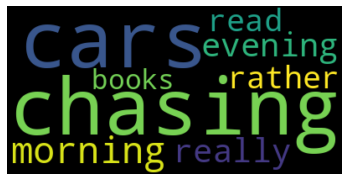

In [2]:
# example 4 final, plotting a word cloud
# !pip install --upgrade pillow

import matplotlib.pyplot as plt
import PIL
print(PIL.__version__)

from wordcloud import WordCloud
from wordcloud import STOPWORDS

sentence="I like chasing cars in the morning. In the evening however, I really don't like chasing cars. I would rather read books."
print(sentence)

# Create and generate a word cloud image:
wordcloud = WordCloud(stopwords=STOPWORDS).generate(sentence)

# Display the generated image:
plt.imshow(wordcloud, interpolation='bilinear')

# bilinear interpolation is a way to spread the words out without them bumping into one another
plt.axis("off")
plt.show()

# Do you notice some words missing? Did you remove stopwords? Have a go at loading a file in.
# Articles such as i and the are missing. I've removed the stopwords



We've seen some very simple examples of what we can do here. Use this boiletplate code to pick a 'theme' of your own. Find a dataset that contains some words and see if you can work through the data processing pipeline in the same way.

Finally, see if you can share a mini analysis of your own using some or even all of the tools you have learned about.